# ESS 배터리 수명 예측 — 탐색적 데이터 분석
울산 1반 U018 원종현

초기 100사이클의 측정값에서 Cycle Life 예측 신호를 찾고, Batch 1·2·3의 차이를 비교한다. 예측 태스크는 **회귀**다.

## 목차
1. 원본 데이터 로딩·구조·품질 점검
2. Q1. Cycle Life 분포
3. Q2. 방전 용량 열화 및 Knee point
4. Q3. 초기 ΔQ(V) 곡선
5. Q4. 충전 조건과 수명
6. Q5. 초기 피처의 상관관계·다중공선성
7. 모델 설계 전략

각 절에서 데이터를 직접 가공하고 통계와 그래프를 계산한다. 저장된 분석 JSON·CSV·PNG나 외부 분석 모듈을 읽어 결과를 대신하지 않는다. 원본 MAT 3개를 `data/raw`에 준비하거나 `BATTERY_DATA_DIR`를 지정하고 위에서 아래로 실행한다. 제출 노트북에는 실행 결과가 포함된다.

In [1]:
from pathlib import Path
import os
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy.ndimage import median_filter
from scipy.stats import spearmanr, pearsonr, skew, kurtosis
from IPython.display import display, Markdown
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists()))
DATA = Path(os.environ.get('BATTERY_DATA_DIR', ROOT / 'data/raw'))
OUTPUT = ROOT / 'results/figures'
OUTPUT.mkdir(parents=True, exist_ok=True)
FILES = {'B1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat', 'B2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat', 'B3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat'}
missing = [name for name in FILES.values() if not (DATA / name).is_file()]
if missing:
    raise FileNotFoundError(f'data/raw에 원본 MAT를 준비하거나 BATTERY_DATA_DIR를 지정하세요: {missing}')
font = Path('/System/Library/Fonts/AppleSDGothicNeo.ttc')
if font.exists():
    font_manager.fontManager.addfont(str(font))
plt.rcParams.update({'font.family': ['DejaVu Sans', 'Apple SD Gothic Neo'], 'axes.unicode_minus': False, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False, 'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white', 'axes.grid': True, 'grid.alpha': 0.17})
COLORS = {'B1': '#167c80', 'B2': '#dd7745', 'B3': '#6162aa'}
COL = COLORS
rng = np.random.default_rng(20261001)

## 원본 데이터 로딩 및 구조
MATLAB v7.3 파일의 셀 참조를 `h5py`로 읽는다. 각 셀의 메타데이터, 모든 사이클의 `summary`, cycle 10·100의 `Qdlin`과 충전 시계열을 메모리에 저장한다. 수명 라벨이나 사이클 번호를 다시 만들지 않는다. 아래 구조 표는 실제 원본 첫 셀에서 자료형·크기·예시를 추출한다.

In [2]:
UNITS = {'cycle_life': 'cycles', 'Vdlin': 'V', 'IR': 'Ω', 'QCharge': 'Ah', 'QDischarge': 'Ah', 'Tavg': '°C', 'Tmax': '°C', 'Tmin': '°C', 'chargetime': 'min', 'cycle': 'cycles', 'I': 'C-rate', 'Qc': 'Ah', 'Qd': 'Ah', 'Qdlin': 'Ah', 'T': '°C', 'Tdlin': '°C', 'V': 'V', 't': 'min', 'discharge_dQdV': 'Ah/V'}
metadata = []
cells = {}
summary_frames = []
structure_rows = []
for batch, filename in FILES.items():
    with h5py.File(DATA / filename, 'r') as f:
        b = f['batch']
        for index in range(len(b['summary'])):
            cell = f'{batch}-C{index + 1:02d}'
            summary_group = f[b['summary'][index, 0]]
            cycle_group = f[b['cycles'][index, 0]]
            summary = {key: np.asarray(summary_group[key], dtype=float).ravel() for key in summary_group}
            life = float(np.asarray(f[b['cycle_life'][index, 0]]).item())
            policy = ''.join((chr(int(v)) for v in np.asarray(f[b['policy_readable'][index, 0]]).ravel()))
            voltage = np.asarray(f[b['Vdlin'][index, 0]], dtype=float).ravel()
            metadata.append({'cell': cell, 'batch': batch, 'file': filename, 'index_1based': index + 1, 'policy': policy, 'life_raw': life, 'n_cycles': len(summary['cycle']), 'q_end': summary['QDischarge'][-1], 'q_invalid_count': int(((summary['QDischarge'] <= 0) | (summary['QDischarge'] > 1.3) | ~np.isfinite(summary['QDischarge'])).sum())})
            cell_data = {'summary': summary, 'v': voltage, 'charge': {}}
            if len(summary['cycle']) >= 100:
                assert np.array_equal(summary['cycle'], np.arange(1, len(summary['cycle']) + 1))
                for number in [10, 100]:
                    j = number - 1
                    cell_data[f'q{number}'] = np.asarray(f[cycle_group['Qdlin'][j, 0]], dtype=float).ravel()
                    cell_data['charge'][number] = {key: np.asarray(f[cycle_group[key][j, 0]], dtype=float).ravel() for key in ['t', 'I', 'Qc']}
                cell_data['current'] = cell_data['charge'][10]
            cells[cell] = cell_data
            frame = pd.DataFrame(summary)
            frame.insert(0, 'cell', cell)
            frame.insert(1, 'batch', batch)
            summary_frames.append(frame)
            if batch == 'B1' and index == 0:
                for key in b:
                    value = f[b[key][index, 0]]
                    if isinstance(value, h5py.Group):
                        dtype, shape, example = ('dict / MATLAB struct', 'nested fields', list(value.keys()))
                    else:
                        array = np.asarray(value)
                        dtype, shape = (str(array.dtype), str(array.shape))
                        example = policy if key == 'policy_readable' else array.ravel()[:3].tolist()
                    structure_rows.append({'level': 'cell', 'field': key, 'dtype': dtype, 'shape': shape, 'unit': UNITS.get(key, '—'), 'example': example})
                for level, group in [('summary', summary_group), ('cycles', cycle_group)]:
                    for key in group:
                        value = group[key] if level == 'summary' else f[group[key][9, 0]]
                        array = np.asarray(value)
                        structure_rows.append({'level': level, 'field': key, 'dtype': str(array.dtype), 'shape': str(array.shape), 'unit': UNITS.get(key, '—'), 'example': array.ravel()[:3].tolist()})
metadata = pd.DataFrame(metadata)
summary_df = pd.concat(summary_frames, ignore_index=True)
structure = pd.DataFrame(structure_rows)
for level, group in structure.groupby('level', sort=False):
    display(Markdown(f'### {level} 필드'))
    display(group.drop(columns='level').reset_index(drop=True))
display(summary_df.head())

### cell 필드

,field,dtype,shape,unit,example
0,Vdlin,float64,"(1, 1000)",V,"[3.5, 3.4984984984984986, 3.496996996996997]"
1,barcode,uint32,"(1, 6)",—,"[3707764736, 2, 1]"
2,channel_id,uint32,"(1, 6)",—,"[3707764736, 2, 1]"
3,cycle_life,float64,"(1, 1)",cycles,[1190.0]
4,cycles,dict / MATLAB struct,nested fields,—,"[I, Qc, Qd, Qdlin, T, Tdlin, V, discharge_dQdV..."
5,policy,uint16,"(15, 1)",—,"[51, 95, 54]"
6,policy_readable,uint16,"(14, 1)",—,3.6C(80%)-3.6C
7,summary,dict / MATLAB struct,nested fields,—,"[IR, QCharge, QDischarge, Tavg, Tmax, Tmin, ch..."


### summary 필드

,field,dtype,shape,unit,example
0,IR,float64,"(1, 1189)",Ω,"[0.0, 0.016742354, 0.016724309]"
1,QCharge,float64,"(1, 1189)",Ah,"[0.0, 1.0710422, 1.0716741]"
2,QDischarge,float64,"(1, 1189)",Ah,"[0.0, 1.0706892, 1.0719005]"
3,Tavg,float64,"(1, 1189)",°C,"[0.0, 31.875010776448963, 31.931490327663376]"
4,Tmax,float64,"(1, 1189)",°C,"[0.0, 35.652016, 35.692978]"
5,Tmin,float64,"(1, 1189)",°C,"[0.0, 29.56613, 29.604385]"
6,chargetime,float64,"(1, 1189)",min,"[0.0, 13.341250000000006, 13.42577666666666]"
7,cycle,float64,"(1, 1189)",cycles,"[1.0, 2.0, 3.0]"


### cycles 필드

,field,dtype,shape,unit,example
0,I,float64,"(1, 1130)",C-rate,"[0.0, 0.25210380909090907, 0.3961762545454545]"
1,Qc,float64,"(1, 1130)",Ah,"[0.0, 1.8984828e-06, 1.8984828e-06]"
2,Qd,float64,"(1, 1130)",Ah,"[0.0, 0.0, 0.0]"
3,Qdlin,float64,"(1, 1000)",Ah,"[-0.0003972576780856493, -0.000355843676556197..."
4,T,float64,"(1, 1130)",°C,"[31.859566, 31.859566, 31.859566]"
5,Tdlin,float64,"(1, 1000)",°C,"[29.73730836649226, 29.737839416301867, 29.738..."
6,V,float64,"(1, 1130)",V,"[2.0231733, 2.0380116, 2.0511627]"
7,discharge_dQdV,float64,"(1, 1000)",Ah/V,"[-0.00837147840167905, -0.00837147840167905, -..."
8,t,float64,"(1, 1130)",min,"[0.0, 0.002649999999994179, 0.0031316666666195..."


,cell,batch,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
0,B1-C01,B1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
1,B1-C01,B1,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250,2.0
2,B1-C01,B1,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777,3.0
3,B1-C01,B1,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167,4.0
4,B1-C01,B1,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442,5.0


### 수명 라벨과 제외 기준
명목 1.1 Ah의 80%인 0.88 Ah를 EOL로 해석한다. 수명 라벨은 원본을 사용하고, 유한 라벨·종료 Qd ≤0.885 Ah를 만족한 셀을 채택한다. 0.005 Ah는 종료 품질 점검의 허용 범위다. B3-C38은 공식 로더에서 수집 문제로 지정한 셀이다. 짧은 수명 자체는 제외 조건이 아니다.

In [4]:
metadata['exclusion'] = ''
metadata.loc[~np.isfinite(metadata.life_raw), 'exclusion'] = '수명 라벨 없음 / EOL 미관측'
metadata.loc[np.isfinite(metadata.life_raw) & (metadata.q_end > 0.885), 'exclusion'] = '우측 검열: 종료 Qd > 0.885 Ah'
metadata.loc[metadata.cell == 'B3-C38', 'exclusion'] = '공식 로더에서 수집 문제 지정'
metadata['included'] = metadata.exclusion.eq('')
metadata['life'] = metadata.life_raw.where(metadata.included)
audit_df = metadata.copy()
cell_df = audit_df.loc[audit_df.included].copy().reset_index(drop=True)
cell_df['newstructure'] = cell_df.policy.str.contains('newstructure', regex=False)

capacity = summary_df.pivot(index='cell', columns='cycle', values='QDischarge')
cell_df['q2'] = cell_df.cell.map(capacity[2].where(capacity[2] > 0))
cell_df['q100'] = cell_df.cell.map(capacity[100].where(capacity[100] > 0))
cell_df['q_ratio'] = cell_df.q100 / cell_df.q2

quality_summary = audit_df.groupby('batch').agg(raw=('cell', 'size'), usable=('included', 'sum')).reset_index()
quality_summary['excluded'] = quality_summary.raw - quality_summary.usable
assert len(audit_df) == 139 and len(cell_df) == 118 and cell_df.cell.is_unique
display(quality_summary)
display(audit_df.loc[~audit_df.included, ['cell', 'batch', 'life_raw', 'q_end', 'exclusion']])

,batch,raw,usable,excluded
0,B1,46,36,10
1,B2,47,39,8
2,B3,46,43,3


,cell,batch,life_raw,q_end,exclusion
0,B1-C01,B1,1190.0,1.026210,우측 검열: 종료 Qd > 0.885 Ah
1,B1-C02,B1,1179.0,1.038225,우측 검열: 종료 Qd > 0.885 Ah
2,B1-C03,B1,1177.0,1.043279,우측 검열: 종료 Qd > 0.885 Ah
3,B1-C04,B1,1226.0,0.970921,우측 검열: 종료 Qd > 0.885 Ah
4,B1-C05,B1,1227.0,1.021960,우측 검열: 종료 Qd > 0.885 Ah
8,B1-C09,B1,879.0,0.969025,우측 검열: 종료 Qd > 0.885 Ah
10,B1-C11,B1,906.0,0.961019,우측 검열: 종료 Qd > 0.885 Ah
12,B1-C13,B1,902.0,0.913119,우측 검열: 종료 Qd > 0.885 Ah
13,B1-C14,B1,897.0,0.923136,우측 검열: 종료 Qd > 0.885 Ah
22,B1-C23,B1,891.0,0.963279,우측 검열: 종료 Qd > 0.885 Ah


### 배치별 데이터 품질과 분석 대상

회색은 제외 셀. 오른쪽 점선 0.885 Ah는 라벨 품질 점검용 허용선이며, EOL 정의 자체는 0.88 Ah이다.

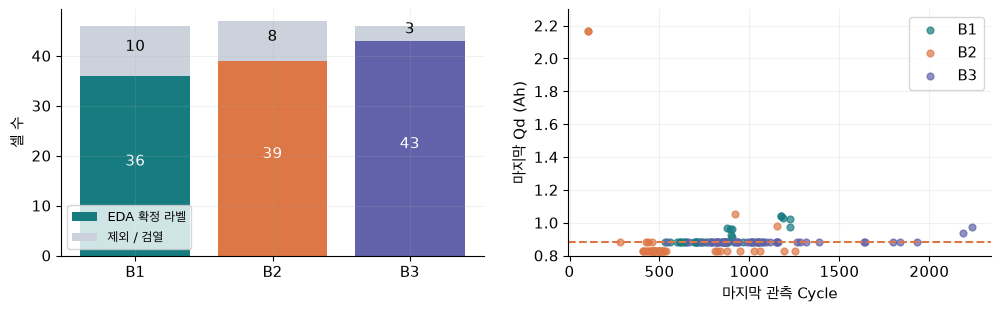

In [5]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].bar(quality_summary.batch, quality_summary.usable, color=[COLORS[b] for b in quality_summary.batch], label='EDA 확정 라벨')
axes[0].bar(quality_summary.batch, quality_summary.excluded, bottom=quality_summary.usable, color='#cbd2db', label='제외 / 검열')
for i, r in quality_summary.iterrows():
    axes[0].text(i, r.usable / 2, str(int(r.usable)), ha='center', color='white')
    axes[0].text(i, r.usable + r.excluded / 2, str(int(r.excluded)), ha='center')
axes[0].set_ylabel('셀 수')
axes[0].legend(fontsize=9)
for b in COLORS:
    g = audit_df[audit_df.batch == b]
    axes[1].scatter(g.n_cycles, g.q_end, c=COLORS[b], label=b, marker='o', s=24, alpha=0.7)
axes[1].axhline(0.885, c='#dd7745', ls='--')
axes[1].set(xlabel='마지막 관측 Cycle', ylabel='마지막 Qd (Ah)', ylim=(0.8, 2.3))
axes[1].legend()
plt.savefig(OUTPUT / ('data_quality' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

139셀 중 B1 36셀, B2 39셀, B3 43셀을 사용한다. 종료 용량 기준은 라벨 품질을 점검하는 기준이며 새로운 수명 라벨을 계산하는 기준은 아니다. 초기 구간 분석에서도 0 이하 또는 1.3 Ah 초과의 Qd를 마스킹하고 원래 사이클 번호를 유지한다.

## Q1. Cycle Life 분포

In [6]:
distribution = cell_df.groupby('batch').life.agg(['count', 'mean', 'median', 'std', 'min', 'max'])
distribution['q25'] = cell_df.groupby('batch').life.quantile(0.25)
distribution['q75'] = cell_df.groupby('batch').life.quantile(0.75)
groups = cell_df.assign(short=cell_df.life < 500, long=cell_df.life > 1000).groupby('batch')[['short', 'long']].sum()
distribution = distribution.join(groups)
distribution['short_pct'] = 100 * distribution.short / distribution['count']
distribution['long_pct'] = 100 * distribution.long / distribution['count']
iqr = distribution.q75 - distribution.q25
distribution['lower_fence'] = distribution.q25 - 1.5 * iqr
distribution['upper_fence'] = distribution.q75 + 1.5 * iqr
display(distribution)

,count,mean,median,std,min,max,q25,q75,short,long,short_pct,long_pct,lower_fence,upper_fence
batch,,,,,,,,,,,,,,
B1,36,788.416667,772.5,148.695734,534.0,1074.0,681.0,871.5,0,5,0.000000,13.888889,395.25,1157.25
B2,39,565.743590,472.0,222.201629,392.0,1186.0,439.5,508.5,28,3,71.794872,7.692308,336.00,612.00
B3,43,1051.976744,1002.0,313.370577,541.0,1935.0,828.0,1150.5,0,22,0.000000,51.162791,344.25,1634.25


### 배치별 Cycle Life 히스토그램

100 cycles 간격의 히스토그램. 점선은 500 / 1,000 cycles 기준이다. 유효 라벨 범위는 실제로 392–1,935 cycles다.

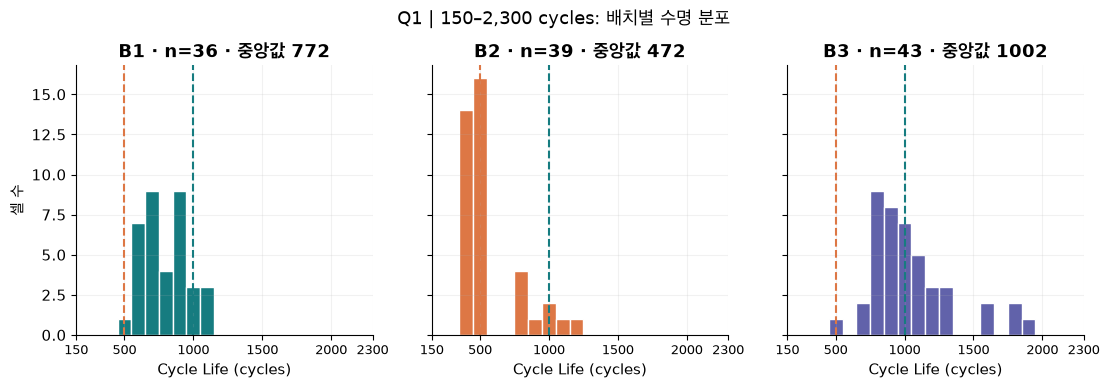

In [7]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharex=True, sharey=True)
bins = np.arange(150, 2351, 100)
for ax, (b, g) in zip(axes, cell_df.groupby('batch')):
    ax.hist(g.life, bins=bins, color=COLORS[b], edgecolor='white')
    ax.axvline(500, c='#dd7745', ls='--')
    ax.axvline(1000, c='#167c80', ls='--')
    ax.set(title=f'{b} · n={len(g)} · 중앙값 {g.life.median():.0f}', xlabel='Cycle Life (cycles)', xlim=(150, 2300))
    ax.set_xticks([150, 500, 1000, 1500, 2000, 2300])
    ax.tick_params(axis='x', labelsize=9)
axes[0].set_ylabel('셀 수')
fig.suptitle('Q1 | 150–2,300 cycles: 배치별 수명 분포', y=1.04)
plt.savefig(OUTPUT / ('q1_histogram' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### 배치별 수명 분포와 장·단수명 비율

왼쪽은 셀별 점과 박스플롯, 오른쪽 비율의 분모는 각 배치의 유효 라벨 셀 수. 500·1,000은 중간 그룹에 포함한다.

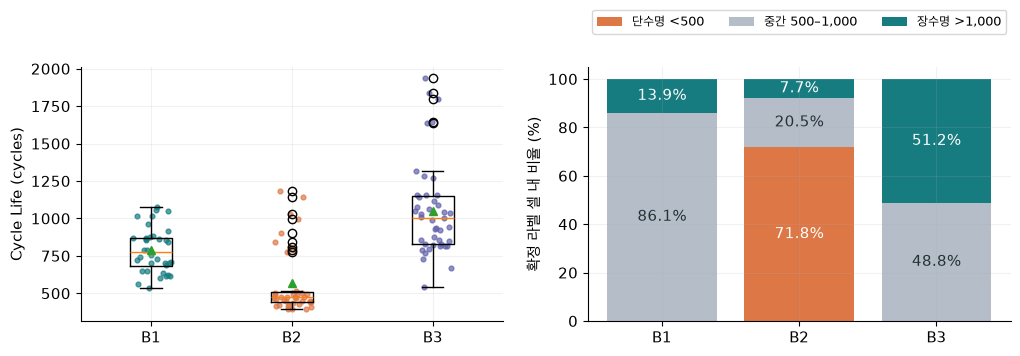

In [8]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 2, figsize=(12, 3.3))
positions = np.arange(3)
axes[0].boxplot([cell_df[cell_df.batch == b].life for b in COLORS], tick_labels=list(COLORS), showmeans=True)
axes[0].set_ylabel('Cycle Life (cycles)')
for b, g in cell_df.groupby('batch'):
    for _, r in g.iterrows():
        axes[0].scatter(list(COLORS).index(b) + 1 + rng.uniform(-0.14, 0.14), r.life, s=12, color=COLORS[b], alpha=0.7)
bottom = np.zeros(3)
for mask, col, label in [(lambda x: x < 500, '#dd7745', '단수명 <500'), (lambda x: (x >= 500) & (x <= 1000), '#b5bdc8', '중간 500–1,000'), (lambda x: x > 1000, '#167c80', '장수명 >1,000')]:
    vals = np.array([mask(cell_df[cell_df.batch == b].life).mean() * 100 for b in COLORS])
    axes[1].bar(list(COLORS), vals, bottom=bottom, color=col, label=label)
    for j, val in enumerate(vals):
        if val > 0:
            axes[1].text(j, bottom[j] + val / 2, f'{val:.1f}%', ha='center', va='center', color='white' if col != '#b5bdc8' else '#233')
    bottom += vals
axes[1].set_ylabel('확정 라벨 셀 내 비율 (%)')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=3, fontsize=9)
plt.savefig(OUTPUT / ('q1_groups' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

배치별 중앙값은 B1 772.5, B2 472, B3 1,002사이클이다. 단수명(<500) 28셀은 모두 B2에 있으며 장수명(>1,000)은 총 30셀이다. B2는 짧은 수명 집단과 긴 꼬리가 혼재해 평균 하나로 설명하기 어렵다. B1의 학습 범위에 없는 단수명으로의 외삽을 별도로 고려해야 한다.

In [10]:
cell_df['low_life_outlier'] = cell_df.life < cell_df.batch.map(distribution.lower_fence)
cell_df['high_life_outlier'] = cell_df.life > cell_df.batch.map(distribution.upper_fence)
display(cell_df.groupby('batch')[['low_life_outlier', 'high_life_outlier']].sum())
display(cell_df.loc[cell_df.groupby('batch').life.idxmin(), ['cell', 'batch', 'life', 'policy', 'q2', 'q100']])

,low_life_outlier,high_life_outlier
batch,,
B1,0,0
B2,0,9
B3,0,5


,cell,batch,life,policy,q2,q100
11,B1-C21,B1,534.0,5.4C(80%)-5.4C,1.072630,1.061248
55,B2-C20,B2,392.0,6C(60%)-3C,1.090241,1.093059
102,B3-C29,B3,541.0,3.7C(31%)-5.9C-newstructure,1.051867,1.034009


### 배치별 최단수명 셀의 열화 곡선

각 배치 최단수명 셀의 Qd 추이. 오른쪽은 수명과 초기 용량으로 정규화한 비교다.

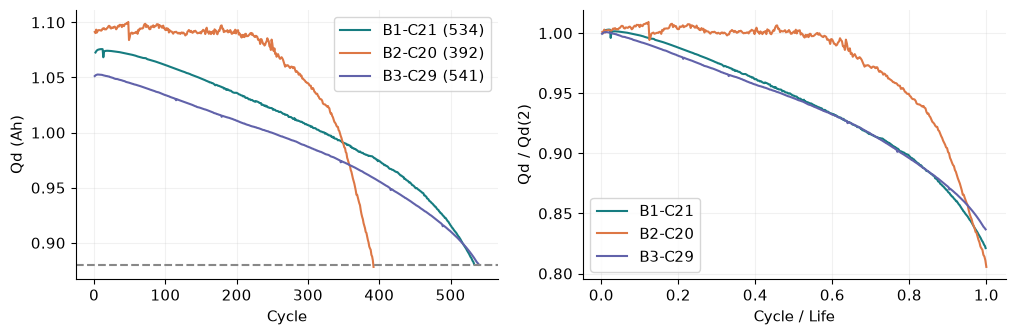

In [11]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for b, g in cell_df.groupby('batch'):
    r = g.sort_values('life').iloc[0]
    s = cells[r.cell]['summary']
    m = (s['cycle'] <= r.life) & (s['QDischarge'] > 0) & (s['QDischarge'] < 1.3)
    axes[0].plot(s['cycle'][m], s['QDischarge'][m], label=f'{r.cell} ({r.life:.0f})', c=COLORS[b])
    axes[1].plot(s['cycle'][m] / r.life, s['QDischarge'][m] / r.q2, label=r.cell, c=COLORS[b])
axes[0].axhline(0.88, c='#888', ls='--')
axes[0].set(xlabel='Cycle', ylabel='Qd (Ah)')
axes[0].legend()
axes[1].set(xlabel='Cycle / Life', ylabel='Qd / Qd(2)')
axes[1].legend()
plt.savefig(OUTPUT / ('q1_shortest' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### 배치별 수명 누적분포

왼쪽은 배치별 경험적 누적분포(ECDF), 오른쪽은 B2의 프로토콜 태그별 분포다. 높이는 해당 수명 이하 셀의 누적 비율이다.

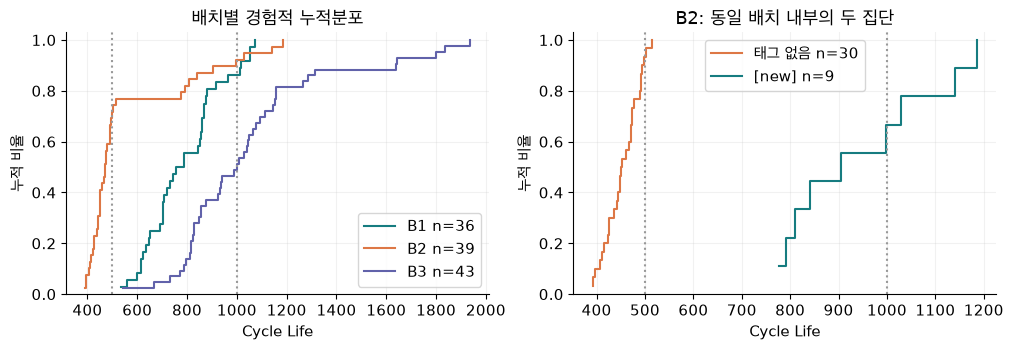

In [12]:
plt.rcParams['axes.titleweight'] = 'normal'
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for b, g in cell_df.groupby('batch'):
    x = np.sort(g.life)
    axes[0].step(x, np.arange(1, len(x) + 1) / len(x), where='post', color=COL[b], label=f'{b} n={len(g)}')
for label, value, col in [('태그 없음', False, '#dd7745'), ('[new]', True, '#167c80')]:
    g = cell_df[(cell_df.batch == 'B2') & (cell_df.newstructure == value)]
    x = np.sort(g.life)
    axes[1].step(x, np.arange(1, len(x) + 1) / len(x), where='post', color=col, label=f'{label} n={len(g)}')
for ax in axes:
    ax.set(xlabel='Cycle Life', ylabel='누적 비율', ylim=(0, 1.03))
    ax.legend()
    ax.axvline(500, ls=':', c='#999')
    ax.axvline(1000, ls=':', c='#999')
axes[0].set_title('배치별 경험적 누적분포')
axes[1].set_title('B2: 동일 배치 내부의 두 집단')
plt.savefig(OUTPUT / ('q1_ecdf' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

배치별 최단수명은 B1-C21(534), B2-C20(392), B3-C29(541)이다. 배치 내부 Tukey 기준에서 저수명 이상치는 없다. 짧은 셀도 실제 열화 궤적을 보이므로 수명이 짧다는 이유로 삭제하지 않는다. B2의 태그 집단 차이가 관찰되지만 태그의 물리적 의미와 조기 종료 원인은 이 EDA만으로 확정할 수 없다.

## Q2. 방전 용량 열화 및 Knee point

### 전체 사이클의 방전 용량 추이

유효 라벨 118개 셀의 Qd 궤적을 수명 시점까지 표시. 색은 수명(짧음: 보라, 김: 노랑). 점선은 EOL 0.88 Ah.

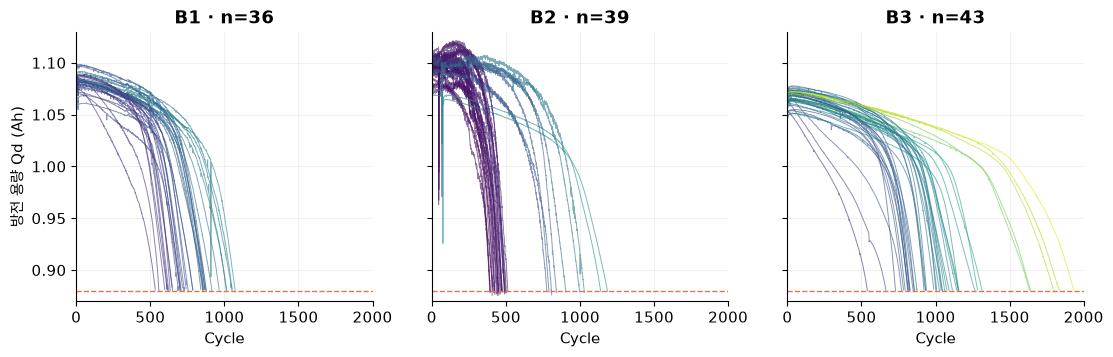

In [13]:
plt.rcParams['axes.titleweight'] = 'bold'
mode = 'full'
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, (b, g) in zip(axes, cell_df.groupby('batch')):
    for _, r in g.iterrows():
        s = cells[r.cell]['summary']
        x = s['cycle']
        q = s['QDischarge']
        m = (q > 0) & (q < 1.3) & (x <= r.life)
        if mode == 'early':
            m &= x <= 100
        qq = np.where(m, q, np.nan)
        ax.plot(x[m] if mode == 'early' else x, qq[m] if mode == 'early' else qq, color=plt.cm.viridis((r.life - 350) / 1650), lw=0.7, alpha=0.6)
    ax.set(title=f'{b} · n={len(g)}', xlabel='Cycle')
    if mode == 'full':
        ax.axhline(0.88, c='#dd7745', ls='--', lw=1)
        ax.set_xlim(0, 2000)
    else:
        ax.set_xlim(1, 100)
axes[0].set_ylabel('방전 용량 Qd (Ah)')
axes[0].set_ylim((0.87, 1.13) if mode == 'full' else (1.0, 1.13))
plt.savefig(OUTPUT / ('q2_' + mode + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### 초기 100사이클의 방전 용량 추이

같은 셀의 초기 100사이클 확대. 초기 용량이 높다고 최종 수명이 긴 것은 아니다.

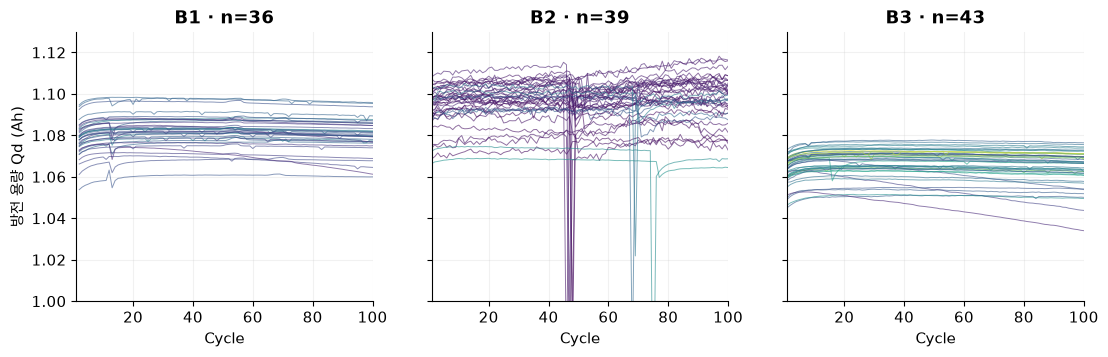

In [17]:
plt.rcParams['axes.titleweight'] = 'bold'
mode = 'early'
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, (b, g) in zip(axes, cell_df.groupby('batch')):
    for _, r in g.iterrows():
        s = cells[r.cell]['summary']
        x = s['cycle']
        q = s['QDischarge']
        m = (q > 0) & (q < 1.3) & (x <= r.life)
        if mode == 'early':
            m &= x <= 100
        qq = np.where(m, q, np.nan)
        ax.plot(x[m] if mode == 'early' else x, qq[m] if mode == 'early' else qq, color=plt.cm.viridis((r.life - 350) / 1650), lw=0.7, alpha=0.6)
    ax.set(title=f'{b} · n={len(g)}', xlabel='Cycle')
    if mode == 'full':
        ax.axhline(0.88, c='#dd7745', ls='--', lw=1)
        ax.set_xlim(0, 2000)
    else:
        ax.set_xlim(1, 100)
axes[0].set_ylabel('방전 용량 Qd (Ah)')
axes[0].set_ylim((0.87, 1.13) if mode == 'full' else (1.0, 1.13))
plt.savefig(OUTPUT / ('q2_' + mode + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

In [18]:
growth = cell_df.assign(capacity_increased=cell_df.q100 > cell_df.q2).groupby('batch').agg(cells=('cell', 'size'), increased=('capacity_increased', 'sum'), median_q2=('q2', 'median'), median_q100=('q100', 'median'))
growth['increased_pct'] = growth.increased / growth.cells * 100
display(growth)

,cells,increased,median_q2,median_q100,increased_pct
batch,,,,,
B1,36,32,1.078399,1.080010,88.888889
B2,39,25,1.095436,1.097549,64.102564
B3,43,36,1.065558,1.066478,83.720930


전체 궤적은 완만한 감소 뒤 후기에 감소가 빨라지는 패턴을 보인다. 초기 100사이클에서는 93/118셀(78.8%)의 용량이 증가한다. 따라서 초기 용량의 직선 감소율을 전체 수명으로 외삽하면 단계별 열화를 놓칠 수 있다. 색은 최종 수명이며 EOL 점선은 0.88 Ah다.

### 연속 두 구간 회귀로 Knee 추정
21점 중앙값 필터로 잡음을 줄이고, 후보 분기점마다 연속 두 구간 회귀를 적합해 SSE가 최소인 점을 찾는다. 초기·후기 기울기 모두 음수, 후기 감소속도 ≥2배, 단일 직선 대비 SSE 개선 ≥25%인 경우만 Knee로 채택한다. 이는 분석상 탐색 기준이며 물리적 사건의 발생 시점을 확정하지 않는다.

In [20]:
def knee_fit(x, y, size=21):
    m = np.isfinite(x) & np.isfinite(y) & (x >= 20) & (y > 0.5) & (y < 1.3)
    x = x[m]
    y = y[m]
    if len(x) < 100:
        return {'knee': np.nan, 'early_slope': np.nan, 'late_slope': np.nan, 'accel_ratio': np.nan, 'knee_gain': np.nan}
    y = median_filter(y, size=size, mode='nearest')
    ids = np.linspace(0, len(x) - 1, min(len(x), 350)).astype(int)
    xx = x[ids]
    yy = y[ids]
    base = np.column_stack([np.ones(len(xx)), xx])
    b = np.linalg.lstsq(base, yy, rcond=None)[0]
    sse0 = np.sum((yy - base @ b) ** 2)
    best = None
    for k in np.linspace(np.quantile(xx, 0.2), np.quantile(xx, 0.85), 100):
        a = np.column_stack([base, np.maximum(0, xx - k)])
        coef = np.linalg.lstsq(a, yy, rcond=None)[0]
        sse = np.sum((yy - a @ coef) ** 2)
        if best is None or sse < best[0]:
            best = (sse, k, coef)
    sse, k, coef = best
    early = coef[1]
    late = early + coef[2]
    ratio = abs(late) / max(abs(early), 1e-08)
    gain = 1 - sse / max(sse0, 1e-15)
    accepted = early < 0 and late < early and (ratio >= 2) and (gain >= 0.25)
    return {'knee': k if accepted else np.nan, 'early_slope': early, 'late_slope': late, 'accel_ratio': ratio, 'knee_gain': gain}

In [21]:
knee_rows = []
for row in cell_df.itertuples():
    s = cells[row.cell]['summary']
    x, q = (s['cycle'], s['QDischarge'])
    mask = (x <= row.life) & (q > 0) & (q < 1.3)
    estimate = knee_fit(x[mask], q[mask])
    estimate['cell'] = row.cell
    estimate['knee_fraction'] = estimate['knee'] / row.life
    candidates = np.array([knee_fit(x[mask], q[mask], width)['knee'] for width in [11, 21, 41]])
    estimate['knee_smoothing_span'] = np.nanmax(candidates) - np.nanmin(candidates) if np.isfinite(candidates).any() else np.nan
    knee_rows.append(estimate)
cell_df = cell_df.merge(pd.DataFrame(knee_rows), on='cell', validate='one_to_one')
knee_summary = cell_df.groupby('batch').agg(cells=('cell', 'size'), detected=('knee', 'count'), knee_cycle_median=('knee', 'median'), knee_fraction_median=('knee_fraction', 'median'), acceleration_median=('accel_ratio', 'median'), early_slope=('early_slope', 'median'), late_slope=('late_slope', 'median'))
display(knee_summary)

,cells,detected,knee_cycle_median,knee_fraction_median,acceleration_median,early_slope,late_slope
batch,,,,,,,
B1,36,36,577.906061,0.750937,10.162228,-0.000074,-0.000793
B2,39,39,342.072727,0.750307,10.234894,-0.000119,-0.001348
B3,43,42,820.507071,0.794032,9.953666,-0.000062,-0.000692


### 대표 셀의 Knee point 추정

배치별 최단수명 셀. 점선은 연속 구간 회귀, 세로선은 SSE가 최소인 변화점.

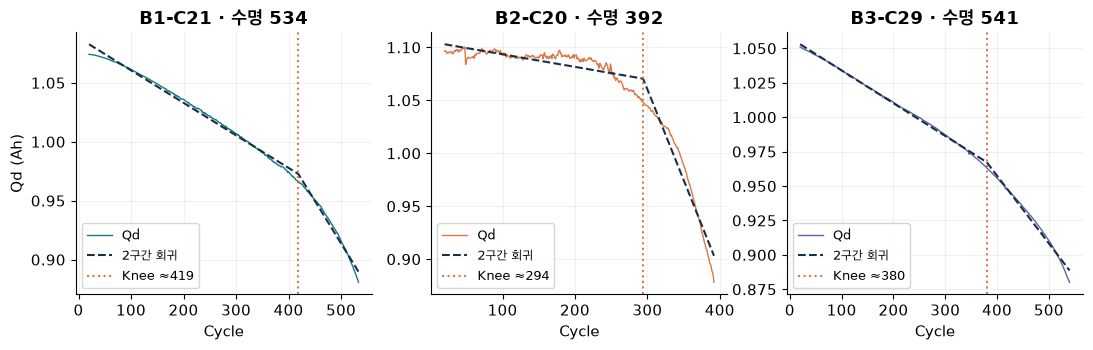

In [22]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (b, g) in zip(axes, cell_df.groupby('batch')):
    r = g.sort_values('life').iloc[0]
    s = cells[r.cell]['summary']
    x = s['cycle']
    q = s['QDischarge']
    m = (x >= 20) & (x <= r.life) & (q > 0) & (q < 1.3)
    ax.plot(x[m], q[m], color=COLORS[b], lw=1, label='Qd')
    k = r.knee
    if np.isfinite(k):
        sm = median_filter(q[m], size=21, mode='nearest')
        a = np.column_stack([np.ones(m.sum()), x[m], np.maximum(0, x[m] - k)])
        coef = np.linalg.lstsq(a, sm, rcond=None)[0]
        ax.plot(x[m], a @ coef, color='#182f46', ls='--', label='2구간 회귀')
        ax.axvline(k, color='#dd7745', ls=':', label=f'Knee ≈{k:.0f}')
    ax.set(title=f'{r.cell} · 수명 {r.life:.0f}', xlabel='Cycle')
    ax.legend(fontsize=9)
axes[0].set_ylabel('Qd (Ah)')
plt.savefig(OUTPUT / ('q2_knees' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### Knee 발생 시점과 열화 가속도

왼쪽은 Knee와 수명 관계, 오른쪽은 후기/초기 기울기 절댓값 비. 117/118 셀이 탐색 기준을 충족한다.

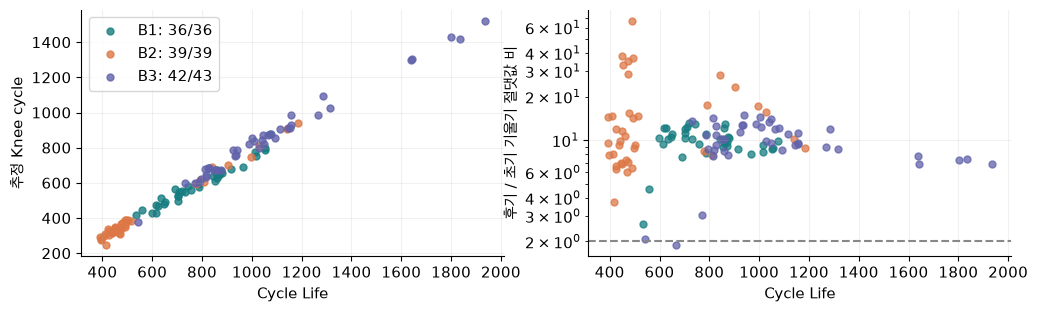

In [23]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
for b, g in cell_df.groupby('batch'):
    axes[0].scatter(g.life, g.knee, color=COLORS[b], label=f'{b}: {g.knee.notna().sum()}/{len(g)}', s=25, alpha=0.8)
    vals = g.accel_ratio.clip(upper=100)
    axes[1].scatter(g.life, vals, color=COLORS[b], s=25, alpha=0.75)
axes[0].set(xlabel='Cycle Life', ylabel='추정 Knee cycle')
axes[0].legend()
axes[1].set(xlabel='Cycle Life', ylabel='후기 / 초기 기울기 절댓값 비')
axes[1].set_yscale('log')
axes[1].axhline(2, ls='--', c='#888')
plt.savefig(OUTPUT / ('q2_knee_summary' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

In [24]:
early = summary_df.loc[summary_df.cycle.between(10, 100)].copy()
early.loc[(early.QDischarge <= 0) | (early.QDischarge >= 1.3), 'QDischarge'] = np.nan
slopes = early.groupby('cell').apply(lambda g: np.polyfit(g.loc[g.QDischarge.notna(), 'cycle'], g.loc[g.QDischarge.notna(), 'QDischarge'], 1)[0], include_groups=False)
cell_df['q_slope'] = cell_df.cell.map(slopes)

### 상대 수명별 용량 유지율과 초기 용량 변화

왼쪽: 11-point 중앙값 평활화 후 상대 수명축으로 보간한 용량 유지율의 셀별 중앙값·사분위 범위. 오른쪽: 초기 용량 증감률. 상대 수명축은 사후 궤적 비교용이다.

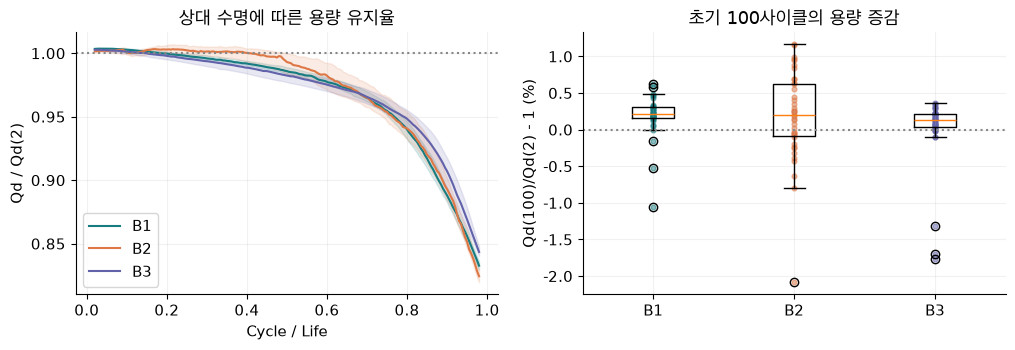

In [25]:
plt.rcParams['axes.titleweight'] = 'normal'
q1 = []
for b, g in cell_df.groupby('batch'):
    q1.append({'batch': b, 'below_800_pct': float((g.life <= 800).mean() * 100), 'cv_pct': float(g.life.std() / g.life.mean() * 100), 'skew': float(g.life.skew())})
stages = []
matrices = {}
grid = np.linspace(0.02, 0.98, 193)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for b, g in cell_df.groupby('batch'):
    mat = []
    for r in g.itertuples():
        s = cells[r.cell]['summary']
        x = s['cycle']
        q = s['QDischarge']
        m = (x >= 2) & (x <= r.life) & (q > 0) & (q < 1.3)
        xx = x[m] / r.life
        yy = median_filter(q[m], size=11, mode='nearest') / r.q2
        mat.append(np.interp(grid, xx, yy))
    mat = np.array(mat)
    med = np.median(mat, axis=0)
    lo, hi = np.quantile(mat, [0.25, 0.75], axis=0)
    axes[0].plot(grid, med, c=COL[b], label=b)
    axes[0].fill_between(grid, lo, hi, color=COL[b], alpha=0.14)
    stages.append({'batch': b, 'n': len(g), 'q2_median': float(g.q2.median()), 'q100_median': float(g.q100.median()), 'growth_median_pct': float((g.q_ratio.median() - 1) * 100), 'early_slope_median_mah': float(g.q_slope.median() * 1000), 'pre_knee_median_mah': float(g.early_slope.median() * 1000), 'post_knee_median_mah': float(g.late_slope.median() * 1000), 'knee_cycle_median': float(g.knee.median()), 'retention_50': float(np.median(mat[:, np.argmin(abs(grid - 0.5))]) * 100), 'retention_75': float(np.median(mat[:, np.argmin(abs(grid - 0.75))]) * 100), 'retention_90': float(np.median(mat[:, np.argmin(abs(grid - 0.9))]) * 100)})
axes[0].set(xlabel='Cycle / Life', ylabel='Qd / Qd(2)', title='상대 수명에 따른 용량 유지율')
axes[0].legend()
axes[0].axhline(1, c='#888', ls=':')
axes[1].boxplot([(g.q_ratio - 1) * 100 for _, g in cell_df.groupby('batch')], tick_labels=list(COL))
for j, (b, g) in enumerate(cell_df.groupby('batch'), 1):
    axes[1].scatter(np.repeat(j, len(g)), (g.q_ratio - 1) * 100, c=COL[b], s=12, alpha=0.5)
axes[1].axhline(0, c='#888', ls=':')
axes[1].set(ylabel='Qd(100)/Qd(2) - 1 (%)', title='초기 100사이클의 용량 증감')
plt.savefig(OUTPUT / ('q2_normalized' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

In [26]:
display(pd.DataFrame(stages))

,batch,n,q2_median,q100_median,growth_median_pct,early_slope_median_mah,pre_knee_median_mah,post_knee_median_mah,knee_cycle_median,retention_50,retention_75,retention_90
0,B1,36,1.078399,1.080010,0.220244,-0.015790,-0.074024,-0.793147,577.906061,98.592010,95.453411,88.803811
1,B2,39,1.095436,1.097549,0.197691,0.019813,-0.118655,-1.347558,342.072727,99.304650,95.381657,89.288025
2,B3,43,1.065558,1.066478,0.130501,-0.015159,-0.062364,-0.692314,820.507071,98.244508,95.761975,90.712110


Knee는 117셀에서 탐색되었고 상대 발생 시점의 배치별 중앙값은 약 75–79%, 후기/초기 속도비는 약 10배다. 상대 사이클·초기 용량으로 정렬한 중앙값과 사분위 범위에서도 후기 가속이라는 공통 패턴이 보인다. 개별 셀의 경로와 Knee 위치는 서로 다르다.

Knee·후기 기울기·최종 수명으로 정규화한 좌표는 미래 정보이므로 모델 입력에서 제외한다. 초기 증가량은 2–100사이클 범위에서만 계산하고 초기 곡선의 미세 변화는 ΔQ(V) 피처로 보완한다.

## Q3. ΔQ(V) = Q100(V) − Q10(V)

In [27]:
dq_rows = []
for row in cell_df.itertuples():
    cell = cells[row.cell]
    delta = cell['q100'] - cell['q10']
    assert len(delta) == len(cell['v']) == 1000 and np.isfinite(delta).all()
    cell['dq'] = delta
    dq_rows.append({'cell': row.cell, 'dq_valid': True, 'dq_logvar': np.log10(max(np.var(delta, ddof=1), 1e-20)), 'dq_logstd': np.log10(max(np.std(delta, ddof=1), 1e-20)), 'dq_logabsmin': np.log10(max(abs(delta.min()), 1e-20)), 'dq_mean': delta.mean(), 'dq_skew': skew(delta, bias=False), 'dq_kurtosis': kurtosis(delta, bias=False)})
cell_df = cell_df.merge(pd.DataFrame(dq_rows), on='cell', validate='one_to_one')
display(cell_df[['cell', 'dq_logvar', 'dq_logabsmin', 'dq_mean', 'dq_skew', 'dq_kurtosis']].head())

,cell,dq_logvar,dq_logabsmin,dq_mean,dq_skew,dq_kurtosis
0,B1-C06,-4.178443,-1.598965,-0.011074,-0.149575,-1.227662
1,B1-C07,-3.768443,-1.421521,-0.015965,-0.408549,-1.238259
2,B1-C08,-3.813052,-1.417557,-0.016646,-0.333918,-1.120135
3,B1-C10,-4.058949,-1.541748,-0.011511,-0.428234,-1.182079
4,B1-C12,-4.146462,-1.625407,-0.008378,-0.595742,-1.205581


In [28]:
def correlation(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[m]
    y = np.asarray(y)[m]
    if len(x) < 4 or np.std(x) == 0 or np.std(y) == 0:
        return (np.nan, np.nan, len(x))
    r, p = spearmanr(x, y)
    return (float(r), float(p), len(x))

### 초기 방전 Q(V) 곡선 비교

각 배치 최단수명 셀의 cycle 10 / 100 방전 Q(V). 두 곡선의 동일 전압 지점끼리 차분한다.

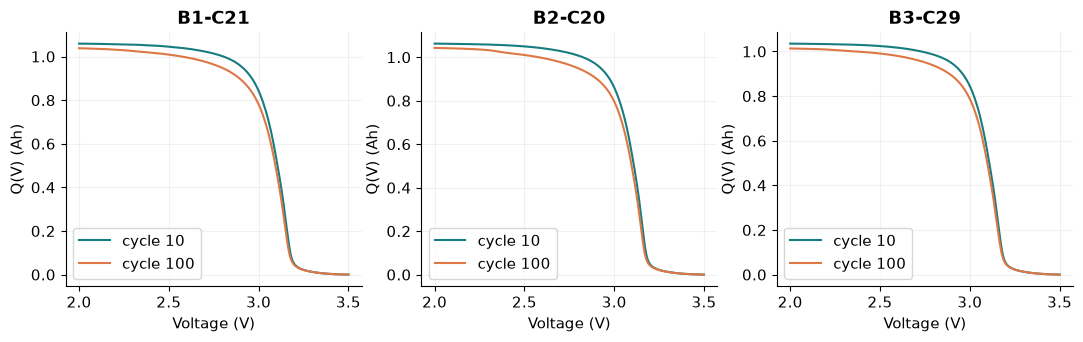

In [29]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for ax, (b, g) in zip(axes, cell_df.groupby('batch')):
    r = g.sort_values('life').iloc[0]
    c = cells[r.cell]
    ax.plot(c['v'], c['q10'], label='cycle 10', c='#167c80')
    ax.plot(c['v'], c['q100'], label='cycle 100', c='#dd7745')
    ax.set(title=r.cell, xlabel='Voltage (V)', ylabel='Q(V) (Ah)')
    ax.legend()
plt.savefig(OUTPUT / ('q3_qv' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### 장·단수명 셀의 ΔQ(V) 비교

장수명 >1,000 / 단수명 <500 비교. 실선=그룹 중앙값, 음영=셀 간 Q25–Q75. 중간 수명은 이 그림에서 제외.

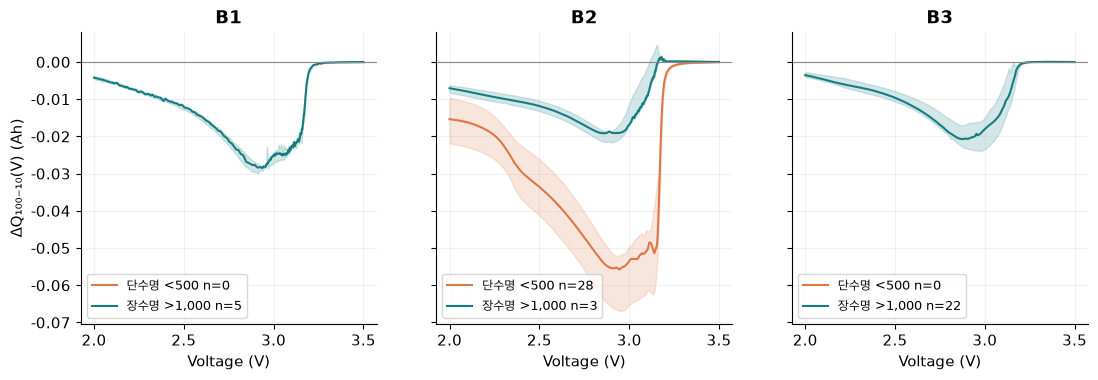

In [30]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (b, g) in zip(axes, cell_df.groupby('batch')):
    for group, mask, col in [('단수명 <500', g.life < 500, '#dd7745'), ('장수명 >1,000', g.life > 1000, '#167c80')]:
        sub = g[mask & g.dq_valid]
        n = len(sub)
        if n:
            mat = np.array([cells[c]['dq'][::-1] for c in sub.cell])
            v = cells[sub.iloc[0].cell]['v'][::-1]
            med = np.median(mat, axis=0)
            lo, hi = np.quantile(mat, [0.25, 0.75], axis=0)
            ax.plot(v, med, c=col, label=f'{group} n={n}')
            ax.fill_between(v, lo, hi, color=col, alpha=0.18)
        else:
            ax.plot([], [], c=col, label=f'{group} n=0')
    ax.set(title=b, xlabel='Voltage (V)')
    ax.axhline(0, c='#888', lw=0.8)
    ax.legend(fontsize=9, loc='lower left')
axes[0].set_ylabel('ΔQ₁₀₀₋₁₀(V) (Ah)')
plt.savefig(OUTPUT / ('q3_group_curves' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### 배치 내부 수명 사분위별 ΔQ(V) 비교

배치 내부 수명의 하위·상위 25%를 비교. 이는 상대 수명 구분으로, <500 / >1,000의 대체 정의가 아니다.

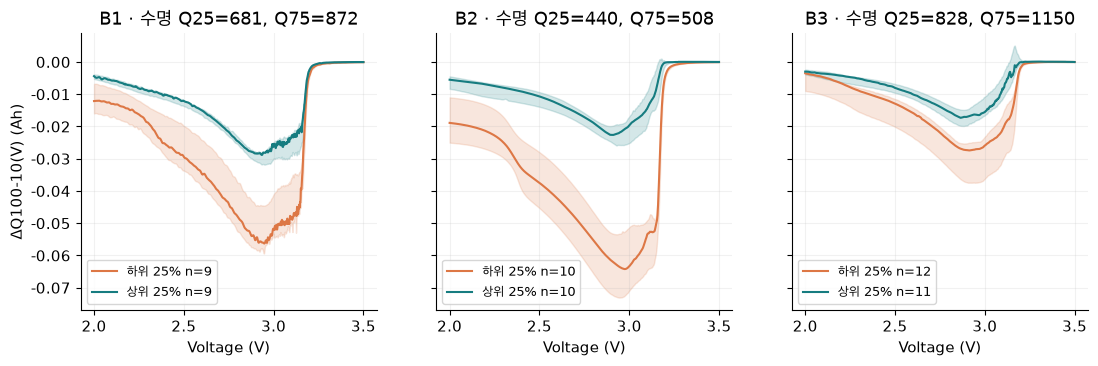

In [31]:
plt.rcParams['axes.titleweight'] = 'normal'
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, (b, g) in zip(axes, cell_df.groupby('batch')):
    lo, hi = g.life.quantile([0.25, 0.75])
    for label, sub, col in [('하위 25%', g[g.life <= lo], '#dd7745'), ('상위 25%', g[g.life >= hi], '#167c80')]:
        mat = np.array([cells[c]['dq'][::-1] for c in sub.cell])
        v = cells[sub.iloc[0].cell]['v'][::-1]
        med = np.median(mat, axis=0)
        low, high = np.quantile(mat, [0.25, 0.75], axis=0)
        ax.plot(v, med, c=col, label=f'{label} n={len(sub)}')
        ax.fill_between(v, low, high, color=col, alpha=0.18)
    ax.set(title=f'{b} · 수명 Q25={lo:.0f}, Q75={hi:.0f}', xlabel='Voltage (V)')
    ax.legend(fontsize=9, loc='lower left')
axes[0].set_ylabel('ΔQ100-10(V) (Ah)')
plt.savefig(OUTPUT / ('q3_relative_groups' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### ΔQ 분산과 Cycle Life의 관계

초기 ΔQ log 분산과 최종 수명. 세 배치 모두 음의 관계가 나타난다. y축은 로그 스케일.

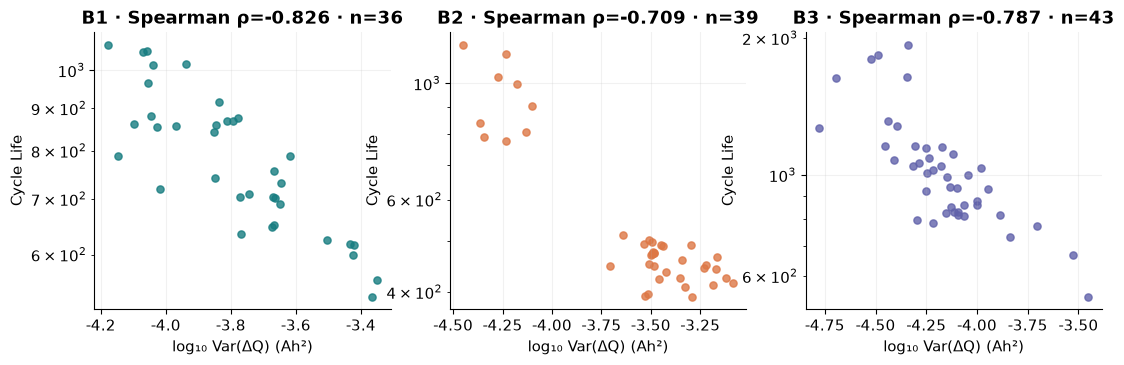

In [32]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (b, g) in zip(axes, cell_df.groupby('batch')):
    rho, _, n = correlation(g.dq_logvar.to_numpy(), g.life.to_numpy())
    ax.scatter(g.dq_logvar, g.life, color=COLORS[b], s=27, alpha=0.8)
    ax.set(title=f'{b} · Spearman ρ={rho:.3f} · n={n}', xlabel='log₁₀ Var(ΔQ) (Ah²)', ylabel='Cycle Life')
    ax.set_yscale('log')
plt.savefig(OUTPUT / ('q3_feature_scatter' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### 전압 구간별 ΔQ 분산과 수명 상관

전압축을 네 구간으로 나누어 각 구간의 ΔQ log 분산과 수명 사이의 Spearman 상관을 계산했다. 구간별 결과도 셀 단위 표본을 사용한다.

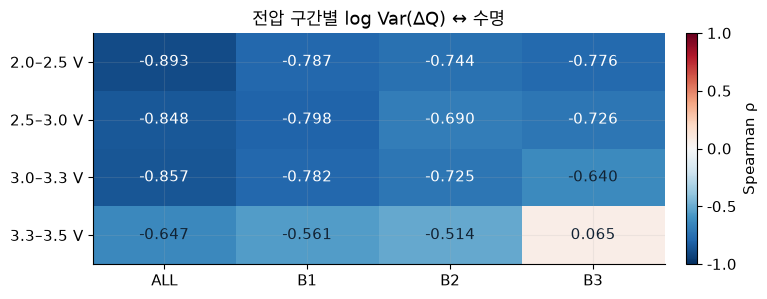

In [33]:
plt.rcParams['axes.titleweight'] = 'normal'
bands = [(2.0, 2.5), (2.5, 3.0), (3.0, 3.3), (3.3, 3.5)]
reg = []
groups = []
for r in cell_df.itertuples():
    c = cells[r.cell]
    for lo, hi in bands:
        m = (c['v'] >= lo) & (c['v'] < hi if hi < 3.5 else c['v'] <= hi)
        var = np.var(c['dq'][m], ddof=1)
        reg.append({'cell': r.cell, 'batch': r.batch, 'life': r.life, 'voltage': f'{lo:.1f}–{hi:.1f} V', 'logvar': np.log10(max(var, 1e-20))})
for b, g in cell_df.groupby('batch'):
    low, high = g.life.quantile([0.25, 0.75])
    for name, sub in [('하위 25%', g[g.life <= low]), ('상위 25%', g[g.life >= high])]:
        points = np.array([np.interp(3.0, cells[c]['v'][::-1], cells[c]['dq'][::-1]) for c in sub.cell])
        groups.append({'batch': b, 'group': name, 'n': len(sub), 'life_median': float(sub.life.median()), 'logvar_median': float(sub.dq_logvar.median()), 'delta_at_3v_mah': float(np.median(points) * 1000), 'min_dq_median_mah': float(np.median([np.min(cells[c]['dq']) for c in sub.cell]) * 1000), 'mean_dq_median_mah': float(sub.dq_mean.median() * 1000)})
R = pd.DataFrame(reg)
region_correlations = []
for b, g in [('ALL', R), *list(R.groupby('batch'))]:
    for voltage, z in g.groupby('voltage'):
        region_correlations.append({'batch': b, 'voltage': voltage, 'rho': float(spearmanr(z.logvar, z.life).statistic), 'n': len(z)})
T = pd.DataFrame(region_correlations).pivot(index='voltage', columns='batch', values='rho').reindex(columns=['ALL', 'B1', 'B2', 'B3'])
fig, ax = plt.subplots(figsize=(9, 3))
a = T.to_numpy()
im = ax.imshow(a, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(4), T.columns)
ax.set_yticks(range(4), T.index)
ax.set_title('전압 구간별 log Var(ΔQ) ↔ 수명')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{a[i, j]:.3f}', ha='center', va='center', color='white' if abs(a[i, j]) > 0.65 else '#123')
fig.colorbar(im, ax=ax, pad=0.03, label='Spearman ρ')
plt.savefig(OUTPUT / ('q3_voltage_regions' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

In [34]:
display(pd.DataFrame(groups))
display(pd.DataFrame(region_correlations))

,batch,group,n,life_median,logvar_median,delta_at_3v_mah,min_dq_median_mah,mean_dq_median_mah
0,B1,하위 25%,9,617.0,-3.432614,-51.935119,-56.415597,-26.764194
1,B1,상위 25%,9,1014.0,-4.045635,-25.431656,-29.095709,-12.628808
2,B2,하위 25%,10,414.0,-3.339084,-63.360001,-64.348208,-31.956505
3,B2,상위 25%,10,872.5,-4.231215,-19.684238,-22.911361,-9.990383
4,B3,하위 25%,12,804.5,-4.078640,-25.920028,-27.859039,-11.862876
5,B3,상위 25%,11,1315.0,-4.439279,-15.531452,-17.457918,-7.131752


,batch,voltage,rho,n
0,ALL,2.0–2.5 V,-0.893402,118
1,ALL,2.5–3.0 V,-0.847517,118
2,ALL,3.0–3.3 V,-0.856633,118
3,ALL,3.3–3.5 V,-0.646685,118
4,B1,2.0–2.5 V,-0.787103,36
5,B1,2.5–3.0 V,-0.798172,36
6,B1,3.0–3.3 V,-0.781825,36
7,B1,3.3–3.5 V,-0.560819,36
8,B2,2.0–2.5 V,-0.744205,39
9,B2,2.5–3.0 V,-0.689645,39


공통 전압축 3.5→2.0 V의 1,000점에서 차이를 계산한다. 장·단수명 비교는 <500·>1,000의 절대 수명 기준이고 배치 내부 사분위 비교는 배치 내부 하위·상위 사분위 기준이다. B1/B3에는 <500셀이 없어 절대 기준과 상대 기준을 구분해야 한다.

log 분산과 수명의 Spearman 상관은 전체 −0.885이고 배치 내부에서도 −0.709~−0.826으로 유지된다. B2의 단수명 28/장수명 3 비교는 장수명 표본이 작다. ΔQ 분산을 기준선으로 두고 최솟값·왜도·첨도의 추가 기여는 B1 내부 검증에서 확인한다.

## Q4. 충전 조건과 Cycle Life

In [35]:
s = summary_df.loc[summary_df.cycle.between(2, 100)].copy()
mean_columns = {'IR': 'ir_mean', 'Tmax': 'tmax_mean', 'Tavg': 'tavg_mean', 'chargetime': 'charge_time'}
for field in mean_columns:
    s[field] = s[field].where((s[field] > 0) & np.isfinite(s[field]))
early_means = s.groupby('cell')[list(mean_columns)].mean().rename(columns=mean_columns)
early_means['temp_span'] = (s.Tmax - s.Tmin).groupby(s.cell).mean()
ir = summary_df.pivot(index='cell', columns='cycle', values='IR')
early_means['ir_delta'] = ir[100].where(ir[100] > 0) - ir[10].where(ir[10] > 0)
last = summary_df.loc[summary_df.cycle.between(91, 100)]
early_means['q_slope_last'] = last.groupby('cell').apply(lambda g: np.polyfit(g.cycle, g.QDischarge, 1)[0], include_groups=False)
cell_df = cell_df.join(early_means, on='cell')
protocol = cell_df.policy.str.extract('([\\d.]+)C\\((\\d+)%\\)-([\\d.]+)C').astype(float)
protocol.columns = ['c1', 'soc_switch', 'c2']
protocol['soc_switch'] /= 100
cell_df = pd.concat([cell_df, protocol], axis=1)
cell_df['c_eff'] = 0.8 / (cell_df.soc_switch / cell_df.c1 + (0.8 - cell_df.soc_switch) / cell_df.c2)
cell_df['step_delta'] = cell_df.c2 - cell_df.c1
cell_df['newstructure'] = cell_df.policy.str.contains('newstructure', regex=False)
current_rows = []
for row in cell_df.itertuples():
    cycle_stats = []
    for number in [10, 100]:
        charge = cells[row.cell]['charge'][number]
        dt = np.diff(charge['t'])
        rates = (charge['I'][:-1] + charge['I'][1:]) / 2
        capacity_mid = (charge['Qc'][:-1] + charge['Qc'][1:]) / 2
        mask = np.isfinite(dt) & np.isfinite(rates) & np.isfinite(capacity_mid) & (dt > 0) & (rates > 0.05) & (capacity_mid <= 0.88)
        if not mask.any():
            cycle_stats.append([np.nan] * 5)
            continue
        weights, rates = (dt[mask], rates[mask])
        mean = np.average(rates, weights=weights)
        cycle_stats.append([mean, np.sqrt(np.average((rates - mean) ** 2, weights=weights)), np.average(rates > 5, weights=weights), rates.max(), weights.sum()])
    values = np.nanmean(cycle_stats, axis=0)
    current_rows.append(dict(cell=row.cell, **dict(zip(['i_mean', 'i_std', 'i_high', 'i_peak', 'i_duration'], values))))
cell_df = cell_df.merge(pd.DataFrame(current_rows), on='cell', validate='one_to_one')
protocol_summary = cell_df.groupby(['batch', 'policy']).life.agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()
display(protocol_summary)

,batch,policy,count,mean,median,std,min,max
0,B1,4.4C(80%)-4.4C,1,1074.000000,1074.0,NaN,1074.0,1074.0
1,B1,4.8C(80%)-4.8C,2,753.000000,753.0,165.462987,636.0,870.0
2,B1,5.4C(40%)-3.6C,1,1054.000000,1054.0,NaN,1054.0,1054.0
3,B1,5.4C(50%)-3C,1,788.000000,788.0,NaN,788.0,788.0
4,B1,5.4C(60%)-3.6C,2,859.500000,859.5,3.535534,857.0,862.0
5,B1,5.4C(60%)-3C,2,799.500000,799.5,113.844192,719.0,880.0
6,B1,5.4C(70%)-3C,2,739.500000,739.5,68.589358,691.0,788.0
7,B1,5.4C(80%)-5.4C,2,546.500000,546.5,17.677670,534.0,559.0
8,B1,6C(30%)-3.6C,1,1014.000000,1014.0,NaN,1014.0,1014.0
9,B1,6C(40%)-3.6C,2,856.000000,856.0,19.798990,842.0,870.0


### 충전 프로토콜별 수명 비교

점=정책별 평균, 선=min–max, n=셀 수. [new]는 문자열의 newstructure 태그. 선은 신뢰구간이 아니다.

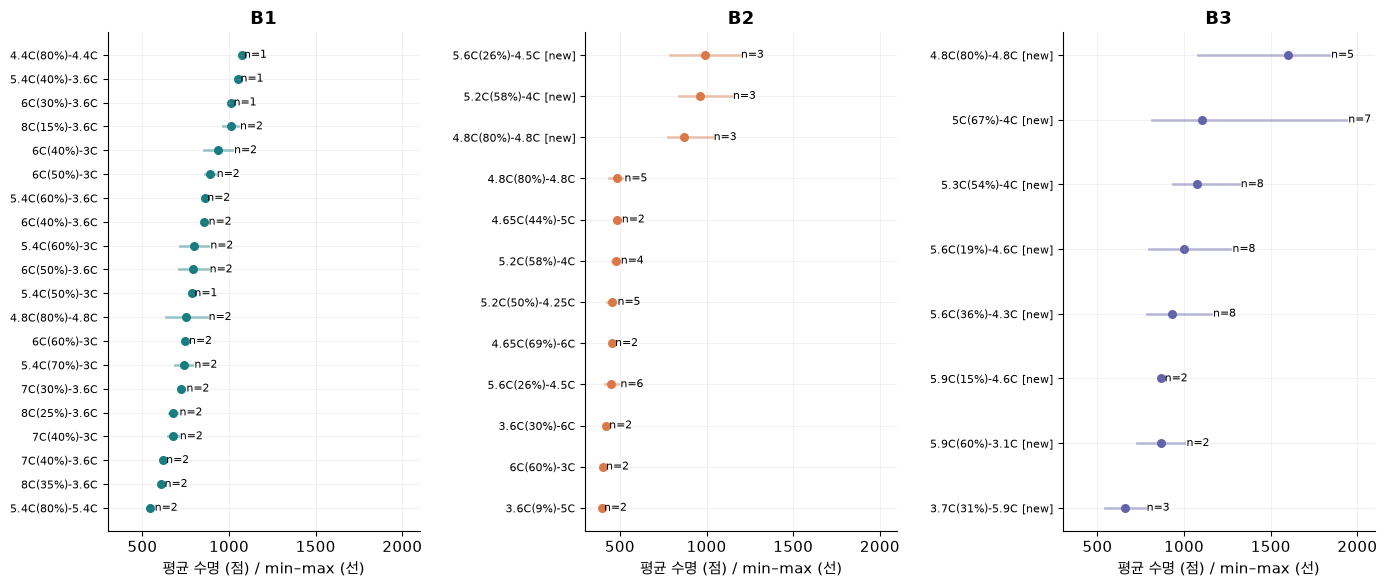

In [36]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
for ax, (b, g) in zip(axes, protocol_summary.groupby('batch')):
    g = g.sort_values('mean')
    short = g.policy.str.replace('-newstructure', ' [new]', regex=False)
    yp = np.arange(len(g))
    ax.scatter(g['mean'], yp, c=COLORS[b], s=30)
    for yy, (_, r) in zip(yp, g.iterrows()):
        ax.plot([r['min'], r['max']], [yy, yy], c=COLORS[b], lw=2, alpha=0.4)
        ax.text(r['max'] + 12, yy, f"n={int(r['count'])}", fontsize=8, va='center')
    ax.set_yticks(yp, short, fontsize=8)
    ax.set(title=b, xlabel='평균 수명 (점) / min–max (선)')
    ax.set_xlim(300, 2100)
fig.tight_layout(w_pad=2)
plt.savefig(OUTPUT / ('q4_protocols' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### 유효 C-rate와 Cycle Life의 관계

0–80% SOC 프로토콜의 유효 C-rate와 수명. B1 ρ=−0.435 / B2 +0.321 / B3 −0.123.

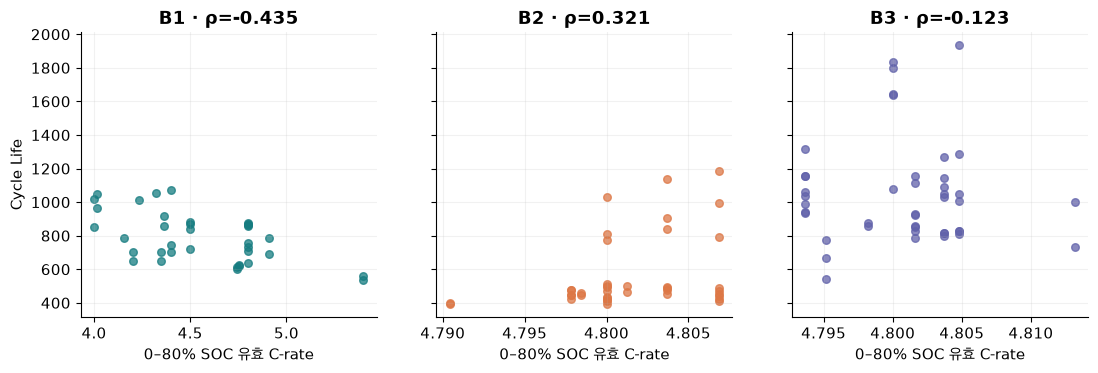

In [37]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 3, figsize=(13, 3.7), sharey=True)
for ax, (b, g) in zip(axes, cell_df.groupby('batch')):
    rho, _, n = correlation(g.c_eff.to_numpy(), g.life.to_numpy())
    ax.scatter(g.c_eff, g.life, c=COLORS[b], s=30, alpha=0.75)
    ax.set(title=f'{b} · ρ={rho:.3f}', xlabel='0–80% SOC 유효 C-rate')
axes[0].set_ylabel('Cycle Life')
plt.savefig(OUTPUT / ('q4_crate' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### 최단·최장수명 셀의 충전 전류 패턴

각 배치의 최단·최장 셀: cycle 10의 실측 충전 전류. Qc ≤0.88 Ah 구간의 원본 I(C-rate)를 표시.

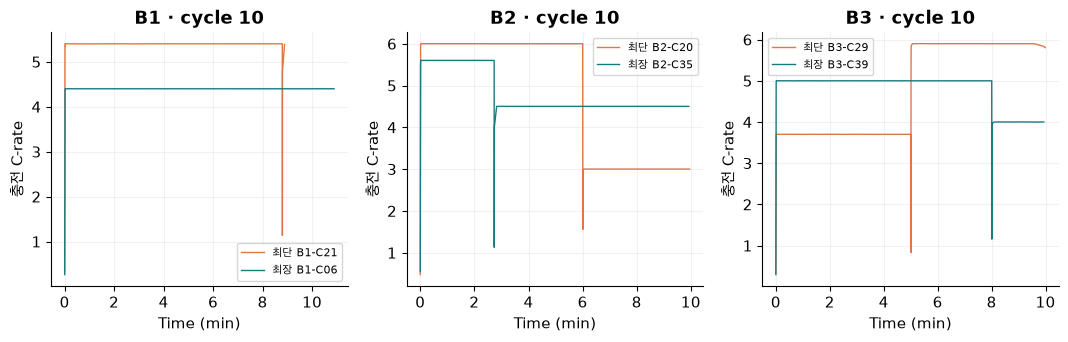

In [38]:
plt.rcParams['axes.titleweight'] = 'bold'
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for ax, (b, g) in zip(axes, cell_df.groupby('batch')):
    for name, grp, col in [('최단', g.nsmallest(1, 'life'), '#dd7745'), ('최장', g.nlargest(1, 'life'), '#167c80')]:
        r = grp.iloc[0]
        c = cells[r.cell]['current']
        m = (c['I'] > 0.05) & (c['Qc'] <= 0.88)
        ax.plot(c['t'][m], c['I'][m], c=col, label=f'{name} {r.cell}', lw=1)
    ax.set(title=f'{b} · cycle 10', xlabel='Time (min)', ylabel='충전 C-rate')
    ax.legend(fontsize=8)
plt.savefig(OUTPUT / ('q4_current_patterns' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

In [39]:
charge_correlations = []
for batch, group in [('ALL', cell_df), *list(cell_df.groupby('batch'))]:
    for feature in ['c1', 'c2', 'c_eff', 'i_mean', 'i_std', 'i_high', 'charge_time', 'step_delta']:
        for target in ['life', 'late_slope', 'q_slope']:
            rho, p, count = correlation(group[feature].to_numpy(), group[target].to_numpy())
            charge_correlations.append({'batch': batch, 'feature': feature, 'target': target, 'rho': rho, 'n': count, 'p': p})
q4 = charge_correlations

In [40]:
LABELS = {'dq_logvar': 'log₁₀ Var(ΔQ)',
 'dq_logabsmin': 'log₁₀ |min ΔQ|',
 'dq_mean': '평균 ΔQ',
 'dq_skew': 'ΔQ 왜도',
 'dq_kurtosis': 'ΔQ 첨도',
 'dq_logstd': 'log₁₀ Std(ΔQ)',
 'q2': 'Qd(2)',
 'q100': 'Qd(100)',
 'q_ratio': 'Qd(100)/Qd(2)',
 'q_slope': 'Qd 기울기 (10–100)',
 'q_slope_last': 'Qd 기울기 (91–100)',
 'ir_mean': '초기 평균 IR',
 'ir_delta': 'IR(100)−IR(10)',
 'tmax_mean': '초기 평균 Tmax',
 'tavg_mean': '초기 평균 Tavg',
 'temp_span': '초기 온도 범위',
 'charge_time': '초기 충전 시간',
 'c1': '1단계 C-rate',
 'c2': '2단계 C-rate',
 'soc_switch': '전환 SOC',
 'c_eff': '프로토콜 유효 C-rate',
 'i_mean': '실측 평균 C-rate',
 'i_std': '실측 전류 변동',
 'i_high': '실측 >5C 시간 비율',
 'i_peak': '실측 최대 C-rate'}
FEATURES = list(LABELS)

### 충전 신호와 수명·열화 속도의 상관

충전 신호와 수명 / 후기 Qd 기울기의 Spearman 상관. 후기 기울기는 더 음수일수록 용량 감소가 빠르다.

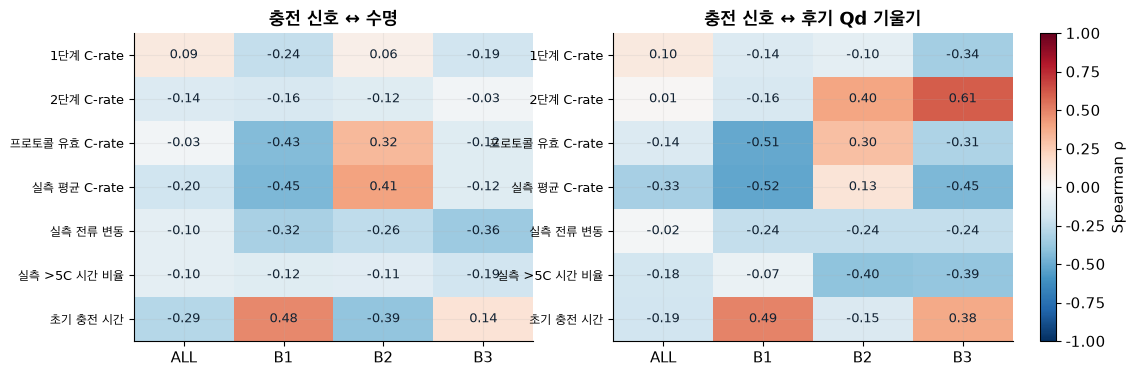

In [41]:
plt.rcParams['axes.titleweight'] = 'bold'
qc = pd.DataFrame(q4)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, target, title in zip(axes, ['life', 'late_slope'], ['충전 신호 ↔ 수명', '충전 신호 ↔ 후기 Qd 기울기']):
    pivot = qc[qc.target == target].pivot(index='feature', columns='batch', values='rho').reindex(index=['c1', 'c2', 'c_eff', 'i_mean', 'i_std', 'i_high', 'charge_time'], columns=['ALL', 'B1', 'B2', 'B3'])
    mat = pivot.to_numpy()
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(4), pivot.columns)
    ax.set_yticks(range(len(pivot)), [LABELS[k] for k in pivot.index], fontsize=9)
    ax.set_title(title)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f'{mat[i, j]:.2f}' if np.isfinite(mat[i, j]) else '—', ha='center', va='center', fontsize=9, color='white' if abs(mat[i, j]) > 0.65 else '#123')
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.03, label='Spearman ρ')
plt.savefig(OUTPUT / ('q4_correlations' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### Batch 2의 프로토콜 태그별 수명 비교

B2의 실측 평균 C-rate와 수명을 태그별로 분리한 산점도, 같은 숫자 정책의 평균 수명 비교. 태그별 표본 수와 관측 범위가 다르다.

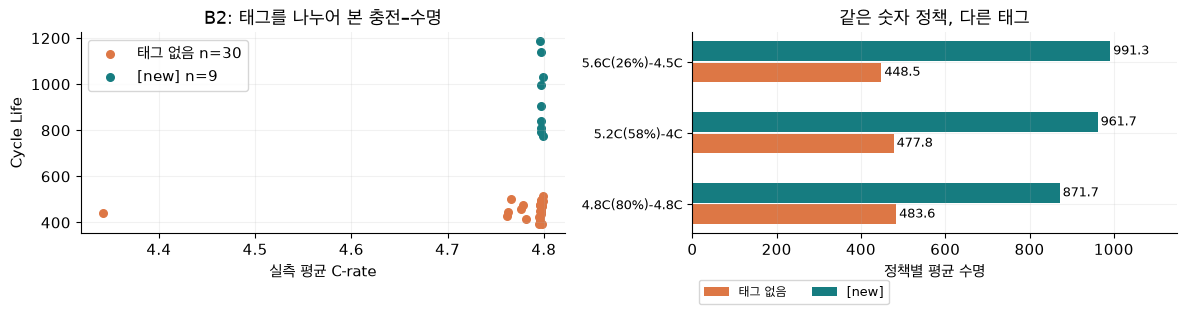

In [42]:
plt.rcParams['axes.titleweight'] = 'normal'
G = cell_df[cell_df.batch == 'B2']
q4 = []
for name, g in [('B2 전체', G), ('B2 태그 없음', G[~G.newstructure]), ('B2 [new]', G[G.newstructure])]:
    q4.append({'group': name, 'n': len(g), 'life_mean': float(g.life.mean()), 'life_median': float(g.life.median()), 'rho_ceff': float(spearmanr(g.c_eff, g.life).statistic), 'rho_imean': float(spearmanr(g.i_mean, g.life).statistic)})
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for name, value, col in [('태그 없음', False, '#dd7745'), ('[new]', True, '#167c80')]:
    g = G[G.newstructure == value]
    axes[0].scatter(g.i_mean, g.life, c=col, label=f'{name} n={len(g)}', s=30)
axes[0].set(xlabel='실측 평균 C-rate', ylabel='Cycle Life', title='B2: 태그를 나누어 본 충전–수명')
axes[0].legend()
policies = ['4.8C(80%)-4.8C', '5.2C(58%)-4C', '5.6C(26%)-4.5C']
yp = np.arange(3)
for label, value, col, offset in [('태그 없음', False, '#dd7745', -0.15), ('[new]', True, '#167c80', 0.15)]:
    vals = [G[(G.policy.str.replace('-newstructure', '', regex=False) == p) & (G.newstructure == value)].life.mean() for p in policies]
    axes[1].barh(yp + offset, vals, height=0.28, color=col, label=label)
    for y, v in zip(yp + offset, vals):
        axes[1].text(v + 7, y, f'{v:.1f}', va='center', fontsize=9)
axes[1].set_yticks(yp, policies, fontsize=9)
axes[1].set(xlabel='정책별 평균 수명', title='같은 숫자 정책, 다른 태그')
axes[1].set_xlim(0, 1150)
axes[1].legend(loc='upper left', bbox_to_anchor=(0, -0.2), ncol=2, fontsize=9)
fig.tight_layout()
plt.savefig(OUTPUT / ('q4_tag_control' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

In [43]:
display(pd.DataFrame(q4))

,group,n,life_mean,life_median,rho_ceff,rho_imean
0,B2 전체,39,565.743590,472.0,0.320790,0.406215
1,B2 태그 없음,30,453.000000,451.0,0.206948,0.327770
2,B2 [new],9,941.555556,904.0,0.316228,-0.283333


최대 C-rate 하나로 수명을 설명하기 어렵다. B1의 8C(15%)–3.6C 평균수명은 1,008.5이지만 8C(35%)–3.6C는 607.5사이클이다. 전환 SOC와 적용 시간이 함께 달라진다. 실측 평균 전류와 수명의 상관은 배치별 −0.446/+0.406/−0.119로 방향도 다르다.

B2에서는 같은 숫자 정책에서도 태그 집단별 평균 수명이 약 1.8–2.2배 다르다. 태그 차이는 관측된 집단 효과이며 고속 충전의 인과효과를 증명하지 않는다. I는 이미 C-rate, 시간은 분이며 전류 집계는 cycle 10·100의 충전 구간을 시간 가중 평균한 값이다. 동일 정책은 같은 그룹으로 묶어 검증한다.

## Q5. 초기 신호 상관 및 다중공선성

In [44]:
correlation_rows = []
for batch, group in [('ALL', cell_df), *list(cell_df.groupby('batch'))]:
    for feature in FEATURES:
        rho, p, count = correlation(group[feature].to_numpy(), group.life.to_numpy())
        complete = group[[feature, 'life']].dropna()
        r = pearsonr(complete[feature], np.log10(complete.life)).statistic if len(complete) > 3 and complete[feature].std() > 0 else np.nan
        correlation_rows.append({'batch': batch, 'feature': feature, 'spearman': rho, 'p_exploratory': p, 'n': count, 'pearson_loglife': r})
feature_correlations = pd.DataFrame(correlation_rows)
partial_rows = []
for feature in FEATURES:
    complete = cell_df[[feature, 'life', 'batch']].dropna().copy()
    ranks = complete[[feature, 'life']].rank()
    centred = ranks - ranks.groupby(complete.batch).transform('mean')
    r = pearsonr(centred[feature], centred.life).statistic if centred[feature].std() > 1e-09 else np.nan
    partial_rows.append({'feature': feature, 'batch_adjusted_rank_r': r})
batch_adjusted = pd.DataFrame(partial_rows)
feature_correlation_matrix = cell_df[FEATURES].corr(method='spearman')
display(feature_correlations.loc[feature_correlations.batch.eq('ALL')].sort_values('spearman', key=abs, ascending=False))
display(batch_adjusted)

,batch,feature,spearman,p_exploratory,n,pearson_loglife
0,ALL,dq_logvar,-0.885054,2.501861e-40,118,-0.901232
5,ALL,dq_logstd,-0.885054,2.501861e-40,118,-0.901232
1,ALL,dq_logabsmin,-0.873531,4.525797e-38,118,-0.877196
2,ALL,dq_mean,0.858160,2.213572e-35,118,0.848820
6,ALL,q2,-0.562734,3.307078e-11,118,-0.584308
7,ALL,q100,-0.532060,5.635937e-10,118,-0.535566
11,ALL,ir_mean,-0.447136,7.717899e-07,112,-0.407008
4,ALL,dq_kurtosis,0.390362,1.242753e-05,118,0.312388
3,ALL,dq_skew,-0.315195,5.080140e-04,118,-0.078093
14,ALL,tavg_mean,0.312189,5.783425e-04,118,0.355102


,feature,batch_adjusted_rank_r
0,dq_logvar,-0.834695
1,dq_logabsmin,-0.814058
2,dq_mean,0.786781
3,dq_skew,-0.178660
4,dq_kurtosis,0.394114
5,dq_logstd,-0.834695
6,q2,0.010673
7,q100,0.034989
8,q_ratio,-0.091688
9,q_slope,-0.121262


### 초기 피처와 Cycle Life의 상관

초기 100사이클 피처와 수명 상관. 배치 보정은 피처·수명의 전체 순위에서 배치 평균을 제거한 뒤 계산한 Pearson 상관.

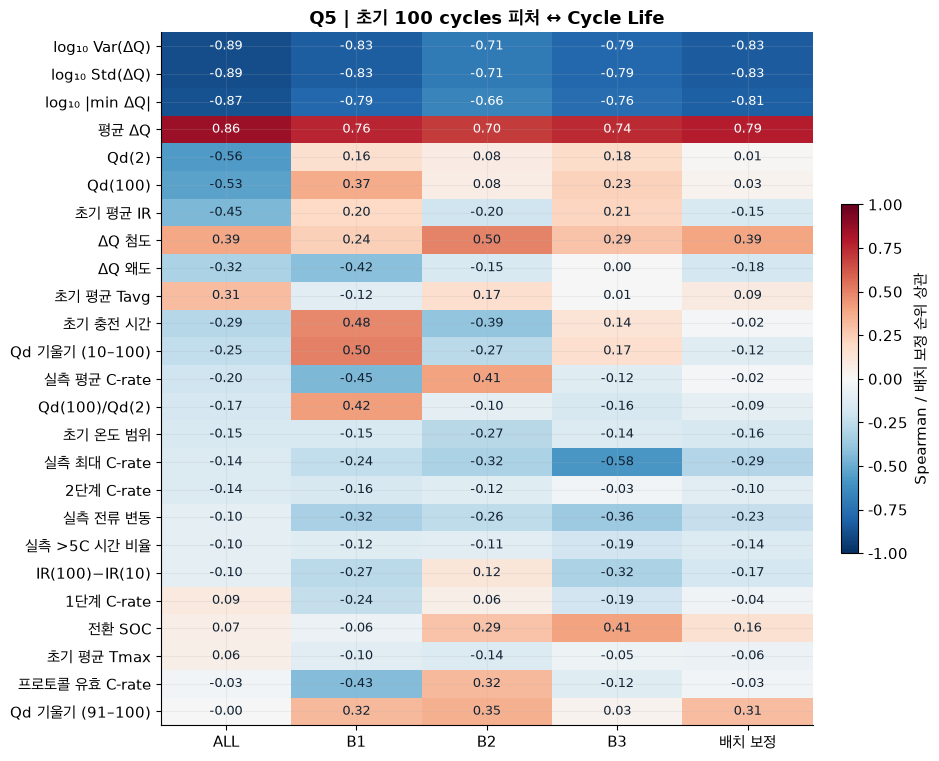

In [45]:
plt.rcParams['axes.titleweight'] = 'bold'
order = feature_correlations[feature_correlations.batch == 'ALL'].sort_values('spearman', key=abs, ascending=False).feature.tolist()
pivot = feature_correlations.pivot(index='feature', columns='batch', values='spearman').reindex(index=order, columns=['ALL', 'B1', 'B2', 'B3'])
pivot['배치 보정'] = batch_adjusted.set_index('feature').batch_adjusted_rank_r
fig, ax = plt.subplots(figsize=(9, 9))
mat = pivot.to_numpy()
im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(5), pivot.columns)
ax.set_yticks(range(len(pivot)), [LABELS[k] for k in pivot.index])
ax.set_title('Q5 | 초기 100 cycles 피처 ↔ Cycle Life')
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f'{mat[i, j]:.2f}' if np.isfinite(mat[i, j]) else '—', ha='center', va='center', fontsize=9, color='white' if abs(mat[i, j]) > 0.65 else '#123')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.04, label='Spearman / 배치 보정 순위 상관')
plt.savefig(OUTPUT / ('q5_target_correlations' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### 초기 피처 간 상관과 다중공선성

피처 간 Spearman 상관. 숫자는 |ρ|≥0.9인 쌍만 표시. log 분산과 log 표준편차는 정확히 중복이다.

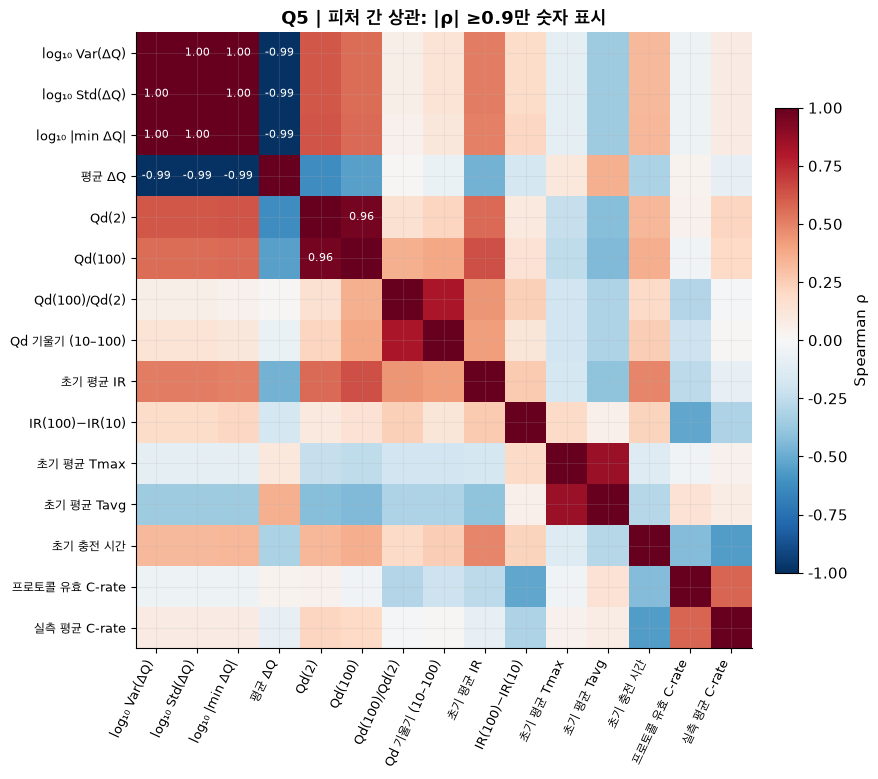

In [40]:
plt.rcParams['axes.titleweight'] = 'bold'
sel = ['dq_logvar', 'dq_logstd', 'dq_logabsmin', 'dq_mean', 'q2', 'q100', 'q_ratio', 'q_slope', 'ir_mean', 'ir_delta', 'tmax_mean', 'tavg_mean', 'charge_time', 'c_eff', 'i_mean']
mat = feature_correlation_matrix.loc[sel, sel].to_numpy()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(sel)), [LABELS[k] for k in sel], rotation=65, ha='right', fontsize=9)
ax.set_yticks(range(len(sel)), [LABELS[k] for k in sel], fontsize=9)
for i in range(len(sel)):
    for j in range(len(sel)):
        if i != j and abs(mat[i, j]) >= 0.9:
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', color='white', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03, label='Spearman ρ')
ax.set_title('Q5 | 피처 간 상관: |ρ| ≥0.9만 숫자 표시')
plt.savefig(OUTPUT / ('q5_collinearity' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

### 초기 용량과 수명 관계의 배치 효과

Qd(2)와 수명 산점도: 전체 배치에서는 음의 관계가 보이지만, 전체 순위에서 배치별 평균 순위를 제거하면 거의 사라진다.

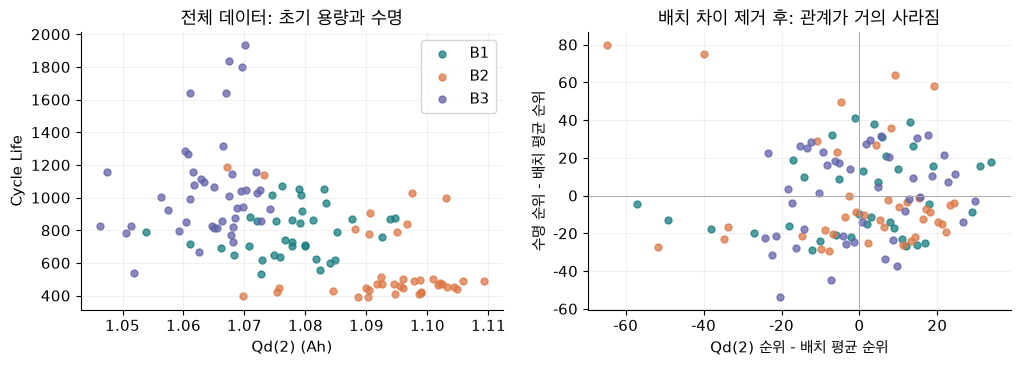

In [46]:
plt.rcParams['axes.titleweight'] = 'normal'
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for b, g in cell_df.groupby('batch'):
    axes[0].scatter(g.q2, g.life, c=COL[b], label=b, s=25, alpha=0.75)
    ax = axes[1]
    rankx = G
rank = cell_df[['q2', 'life', 'batch']].copy()
rank['qrank'] = rank.q2.rank()
rank['yrank'] = rank.life.rank()
rank['qr'] = rank.qrank - rank.groupby('batch').qrank.transform('mean')
rank['yr'] = rank.yrank - rank.groupby('batch').yrank.transform('mean')
for b, g in rank.groupby('batch'):
    axes[1].scatter(g.qr, g.yr, c=COL[b], s=25, alpha=0.75)
axes[0].set(xlabel='Qd(2) (Ah)', ylabel='Cycle Life', title='전체 데이터: 초기 용량과 수명')
axes[0].legend()
axes[1].set(xlabel='Qd(2) 순위 - 배치 평균 순위', ylabel='수명 순위 - 배치 평균 순위', title='배치 차이 제거 후: 관계가 거의 사라짐')
axes[1].axhline(0, c='#aaa', lw=0.7)
axes[1].axvline(0, c='#aaa', lw=0.7)
plt.savefig(OUTPUT / ('q5_batch_confounding' + '.png'), dpi=190, bbox_inches='tight')
plt.show()
plt.close(fig)

In [42]:
pairs = []
for i, feature in enumerate(FEATURES):
    for other in FEATURES[i + 1:]:
        rho = feature_correlation_matrix.loc[feature, other]
        if abs(rho) >= 0.9:
            pairs.append({'feature1': feature, 'feature2': other, 'rho': rho})
display(pd.DataFrame(pairs))
compact = ['dq_logvar', 'q2', 'q_slope_last', 'ir_delta', 'tmax_mean', 'i_high']
z = cell_df[compact].dropna()
z = (z - z.mean()) / z.std()
vif_rows = []
for feature in compact:
    target = z[feature].to_numpy()
    predictors = z.drop(columns=feature).to_numpy()
    fitted = predictors @ np.linalg.lstsq(predictors, target, rcond=None)[0]
    r2 = 1 - np.sum((target - fitted) ** 2) / np.sum(target ** 2)
    vif_rows.append({'feature': feature, 'vif': 1 / (1 - r2), 'n': len(z)})
display(pd.DataFrame(vif_rows))
assert np.allclose(cell_df.dq_logstd, 0.5 * cell_df.dq_logvar)

,feature1,feature2,rho
0,dq_logvar,dq_logabsmin,0.995939
1,dq_logvar,dq_mean,-0.985180
2,dq_logvar,dq_logstd,1.000000
3,dq_logabsmin,dq_mean,-0.987736
4,dq_logabsmin,dq_logstd,0.995939
5,dq_mean,dq_logstd,-0.985180
6,q2,q100,0.960916


,feature,vif,n
0,dq_logvar,2.214889,112
1,q2,2.259738,112
2,q_slope_last,1.159590,112
3,ir_delta,1.032041,112
4,tmax_mean,1.148571,112
5,i_high,1.150408,112


전체 Q2와 수명의 상관 −0.563은 배치 보정 후 +0.011로 약해진다. 초기 용량의 전체 관계에는 배치 차이가 섞여 있다. 반면 ΔQ 분산은 배치 보정 후에도 약 −0.835의 관계를 유지한다.

log 표준편차는 log 분산의 0.5배이므로 두 변수를 동시에 입력하지 않는다. ΔQ 평균·최솟값·분산도 높은 중복성을 보인다. Core6의 VIF 최대 약 2.26(n=112)은 초기 진단이며 모델 성능을 보장하지 않는다. 여러 피처군과 정규화 모델의 추가 기여를 B1 내부에서 비교한다.

## 모델 설계 전략
- **피처:** 초기 100사이클의 ΔQ 통계와 초기 용량 증가량을 우선 사용한다. IR·온도·충전의 추가 기여는 피처군 비교로 확인한다. 전체 수명 지표는 입력에서 제외한다.
- **타깃:** log₁₀(Cycle Life) 회귀 후 10**예측값으로 역변환한다. B1에는 <500 셀이 없어 장·단수명 분류의 학습 범위가 제한된다.
- **후보:** ΔQ 단일 기준선, Ridge·ElasticNet·BayesianRidge·Huber, SVR 및 깊이를 제한한 트리·부스팅을 동일한 B1 내부 검증으로 비교한다.
- **검증:** 충전 정책 단위 CV 및 Hold-out을 사용한다. 대치·표준화는 학습 fold에서만 fit한다. B1에서 모델을 확정한 뒤 B2와 B3를 평가한다.
- **선정 근거:** EDA의 신호와 데이터 특성에 맞는 후보를 비교하고 그 범위의 최적 모델을 선택한다. 논문 성능과의 차이는 일반화 한계·오류 분석에 활용한다.

ESS에서는 점검 우선순위와 교체 계획 검토에 활용할 수 있는 신호다. 실 BESS 적용 전에는 현장 데이터, 달력 열화, 온도·SOC·휴지, 팩 불균형과 불확실성 검증이 필요하다.

참고: Severson et al. (2019), *Data-driven prediction of battery cycle life before capacity degradation*, Nature Energy 4, 383–391.